<a href="https://colab.research.google.com/github/AndresMontesDeOca/Deep_Learning/blob/main/MONTESDEOCA-ANDRES-DL-TP3-Co24.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 24 - 2do bimestre 2026


Este tercer y último TP se debe entregar hasta las **23:59hs del viernes 19 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía que consideren que les haga falta. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/56R6couXZBPDZzfs5)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP3-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

Les recomiendo usar el siguiente código para poder obtener las imágenes fácilmente desde ese link. Pero son libres de descargar las imágenes como mejor les parezca.

In [ ]:
# Librerias

import gdown
import zipfile
import os
import os
import random
import matplotlib.pyplot as plt
from PIL import Image


In [1]:
url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
output = "archivo.zip"

gdown.download(url, output, quiet=False)

destino = "datos_zip"
os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

DATASET_ROOT_TRAIN = '/content/datos_zip/dataset_emociones/train'
DATASET_ROOT_VAL   = '/content/datos_zip/dataset_emociones/validation'


Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=18d376a9-7037-41e0-a64e-d8acda5ab869
To: /content/archivo.zip
100%|██████████| 40.0M/40.0M [00:01<00:00, 35.0MB/s]


In [132]:
# Analisis Distribucion de clases

print("--- TRAIN ---")
train_counts = {}
for clase in sorted(os.listdir(DATASET_ROOT_TRAIN)):
    ruta_clase = os.path.join(DATASET_ROOT_TRAIN, clase)
    if os.path.isdir(ruta_clase):
        train_counts[clase] = len(os.listdir(ruta_clase))

total_train = sum(train_counts.values())
for clase, cantidad in train_counts.items():
    porcentaje = (cantidad / total_train) * 100 if total_train > 0 else 0
    print(f"Clase '{clase}': {cantidad} imágenes ({porcentaje:.2f}%)")
print(f"Total Train: {total_train}\n")

print("--- VALIDATION (TEST) ---")
val_counts = {}
for clase in sorted(os.listdir(DATASET_ROOT_VAL)):
    ruta_clase = os.path.join(DATASET_ROOT_VAL, clase)
    if os.path.isdir(ruta_clase):
        val_counts[clase] = len(os.listdir(ruta_clase))

total_val = sum(val_counts.values())
for clase, cantidad in val_counts.items():
    porcentaje = (cantidad / total_val) * 100 if total_val > 0 else 0
    print(f"Clase '{clase}': {cantidad} imágenes ({porcentaje:.2f}%)")
print(f"Total Validation: {total_val}")

--- TRAIN ---
Clase 'alegria': 4772 imágenes (38.89%)
Clase 'disgusto': 717 imágenes (5.84%)
Clase 'enojo': 705 imágenes (5.75%)
Clase 'miedo': 281 imágenes (2.29%)
Clase 'seriedad': 2524 imágenes (20.57%)
Clase 'sorpresa': 1290 imágenes (10.51%)
Clase 'tristeza': 1982 imágenes (16.15%)
Total Train: 12271

--- VALIDATION (TEST) ---
Clase 'alegria': 1185 imágenes (38.62%)
Clase 'disgusto': 160 imágenes (5.22%)
Clase 'enojo': 162 imágenes (5.28%)
Clase 'miedo': 74 imágenes (2.41%)
Clase 'seriedad': 680 imágenes (22.16%)
Clase 'sorpresa': 329 imágenes (10.72%)
Clase 'tristeza': 478 imágenes (15.58%)
Total Validation: 3068


- Dividido 80/20, bien estratificado por clase
- La distribucion de las clases no es homogenea

## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



--- DICCIONARIO DE CLASES ---
0: Aleatorio
1: Alegria
2: Disgusto
3: Enojo
4: Miedo
5: Seriedad
6: Sorpresa
7: Tristeza
----------------------------------------
--- METADATA DE LAS IMÁGENES (DISGUSTO) ---
[1] Archivo: train_08269_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[2] Archivo: train_04305_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[3] Archivo: train_03017_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[4] Archivo: train_01343_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG


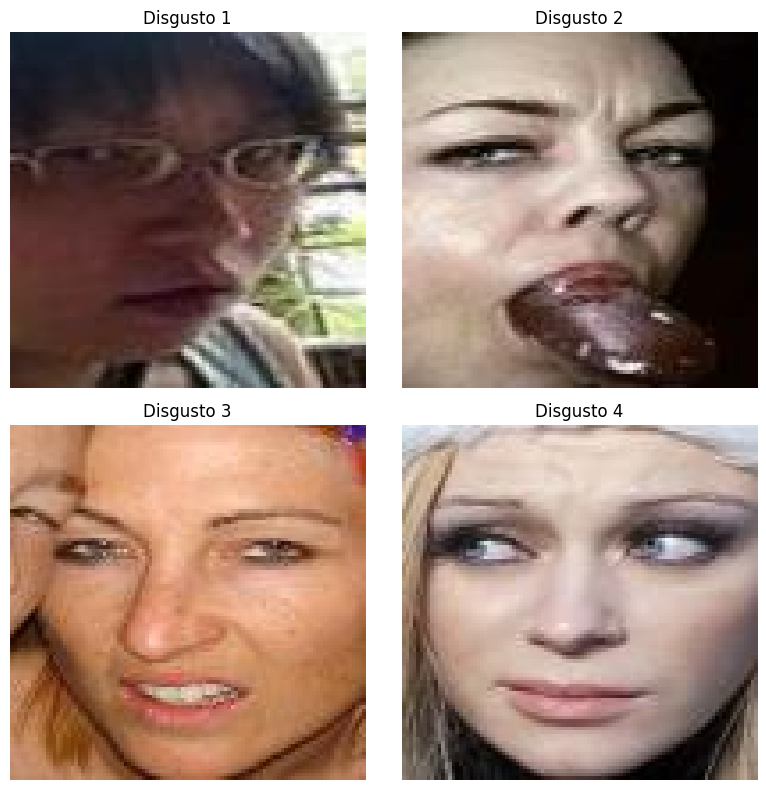

In [133]:
# VISUALIZADOR
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Clases ordenadas alfabéticamente
clases = sorted(os.listdir(DATASET_ROOT_TRAIN))

# Crear y mostrar el diccionario de opciones
diccionario_clases = {i+1: c for i, c in enumerate(clases)}
print("--- DICCIONARIO DE CLASES ---")
print("0: Aleatorio")
for k, v in diccionario_clases.items():
    print(f"{k}: {v.capitalize()}")
print("-" * 40)

# @markdown Ingresa el número de la clase que deseas visualizar:
opcion_clase = 2 # @param {type:"integer"}

if 1 <= opcion_clase <= len(clases):
    clase_seleccionada = diccionario_clases[opcion_clase]
else:
    clase_seleccionada = random.choice(clases)
    print("Opción 0 (o inválida). Clase elegida al azar.")

ruta_clase = os.path.join(DATASET_ROOT_TRAIN, clase_seleccionada)
imagenes_disponibles = [f for f in os.listdir(ruta_clase) if os.path.isfile(os.path.join(ruta_clase, f))]

if imagenes_disponibles:
    # Seleccionar hasta 4 imágenes aleatorias
    cantidad_a_mostrar = min(4, len(imagenes_disponibles))
    imagenes_random = random.sample(imagenes_disponibles, cantidad_a_mostrar)

    print(f"--- METADATA DE LAS IMÁGENES ({clase_seleccionada.upper()}) ---")

    # Crear una cuadrícula de 2x2
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    axes = axes.flatten() # Aplanar para iterar fácilmente

    for i in range(4):
        if i < cantidad_a_mostrar:
            imagen_random = imagenes_random[i]
            ruta_imagen = os.path.join(ruta_clase, imagen_random)
            img = Image.open(ruta_imagen)

            print(f"[{i+1}] Archivo: {imagen_random} | Resolución: {img.size} | Modo: {img.mode} | Formato: {img.format}")

            # Mostrar la imagen con matplotlib
            if img.mode == 'L':
                axes[i].imshow(img, cmap='gray')
            else:
                axes[i].imshow(img)

            axes[i].set_title(f"{clase_seleccionada.capitalize()} {i+1}")

        axes[i].axis('off') # Ocultar ejes incluso si no hay imagen en ese espacio

    plt.tight_layout()
    plt.show()
else:
    print(f"No se encontraron imágenes en la clase {clase_seleccionada}.")

- Imagenes de rostros en primer plano
- Todas las imágenes son 100x100 pixels, 3ch(RGB) y formato JPEG
- Algunas en escalas de grises
- Algunas con el lienzo que no es de 100*100

In [138]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. Definir Transformaciones Básicas (Sin Data Augmentation ni Normalización)
# Solo lo estrictamente necesario para que el modelo de PyTorch lo procese
train_transforms = transforms.Compose([
    transforms.Resize((100, 100)), # Nos aseguramos de la dimensión
    transforms.ToTensor()          # Convertir a Tensor de PyTorch (valores entre 0.0 y 1.0)
])

val_transforms = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

# 2. Cargar los Datasets usando ImageFolder (asume estructura de carpetas por clase)
train_dataset = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=DATASET_ROOT_VAL, transform=val_transforms)

# 3. Crear los DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Clases mapeadas: {train_dataset.class_to_idx}")
print(f"Imágenes para entrenamiento: {len(train_dataset)} -> Batches: {len(train_loader)}")
print(f"Imágenes para validación: {len(val_dataset)} -> Batches: {len(val_loader)}")

Clases mapeadas: {'alegria': 0, 'disgusto': 1, 'enojo': 2, 'miedo': 3, 'seriedad': 4, 'sorpresa': 5, 'tristeza': 6}
Imágenes para entrenamiento: 12271 -> Batches: 192
Imágenes para validación: 3068 -> Batches: 48


## 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

In [135]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Bloque de convolución para emplear en la red
def conv_block(c_in, c_out, k=3, p=1, s=1, pk=2):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, k, padding=p, stride=s),
        nn.ReLU(),
        nn.MaxPool2d(pk)
    )

class EmotionCNN(nn.Module):
    def __init__(self):
        super(EmotionCNN, self).__init__()
        # La entrada es de 3 canales (RGB) y de 100x100 píxeles

        # Extracción de características usando los bloques
        self.features = nn.Sequential(
            conv_block(3, 32),    # 100x100 -> 50x50
            conv_block(32, 64),   # 50x50 -> 25x25
            conv_block(64, 128),  # 25x25 -> 12x12
            conv_block(128, 256)  # 12x12 -> 6x6
        )

        # Clasificador
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # Dropout para reducir el overfitting
            nn.Linear(512, 7)   # 7 clases de emociones
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 1. Instanciar el modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo = EmotionCNN().to(device)

# 2. Función de Costo (Loss)
# Usamos CrossEntropyLoss porque es el estándar para clasificación multiclase
criterion = nn.CrossEntropyLoss()

# 3. Optimizador
# Utilizamos Adam con un Learning Rate estándar de 0.001.
optimizer = optim.Adam(modelo.parameters(), lr=0.001)

# Mostrar el resumen de la arquitectura
print(modelo)
print(f"\nModelo cargado en el dispositivo: {device}")

EmotionCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9216, out_features=512, bi

In [137]:
import time

# Número de épocas
num_epochs = 10

# Listas para guardar el histórico y luego graficar (Punto 3)
history_train_loss = []
history_val_loss = []
history_train_acc = []
history_val_acc = []

print("Iniciando el entrenamiento...")
for epoch in range(num_epochs):
    start_time = time.time()

    # --- FASE DE ENTRENAMIENTO ---
    modelo.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Reiniciar gradientes
        outputs = modelo(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calcular costo
        loss.backward() # Backward pass
        optimizer.step() # Actualizar pesos

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train

    history_train_loss.append(epoch_train_loss)
    history_train_acc.append(epoch_train_acc)

    # --- FASE DE VALIDACIÓN ---
    modelo.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = modelo(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = correct_val / total_val

    history_val_loss.append(epoch_val_loss)
    history_val_acc.append(epoch_val_acc)

    end_time = time.time()

    # Imprimir resultados de la época
    print(f"Epoch [{epoch+1}/{num_epochs}] - Tiempo: {end_time - start_time:.2f}s")
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
    print("-"*50)

print("¡Entrenamiento finalizado!")

Iniciando el entrenamiento...
Epoch [1/10] - Tiempo: 24.05s
Train Loss: 1.6177 | Train Acc: 0.3902
Val Loss: 1.4911 | Val Acc: 0.4381
--------------------------------------------------
Epoch [2/10] - Tiempo: 19.04s
Train Loss: 1.2840 | Train Acc: 0.5264
Val Loss: 1.1067 | Val Acc: 0.6063
--------------------------------------------------
Epoch [3/10] - Tiempo: 19.66s
Train Loss: 1.0983 | Train Acc: 0.6044
Val Loss: 0.9509 | Val Acc: 0.6643
--------------------------------------------------
Epoch [4/10] - Tiempo: 20.30s
Train Loss: 0.9817 | Train Acc: 0.6445
Val Loss: 0.8766 | Val Acc: 0.6913
--------------------------------------------------
Epoch [5/10] - Tiempo: 19.90s
Train Loss: 0.9083 | Train Acc: 0.6767
Val Loss: 0.8208 | Val Acc: 0.7021
--------------------------------------------------
Epoch [6/10] - Tiempo: 19.31s
Train Loss: 0.8564 | Train Acc: 0.6931
Val Loss: 0.7927 | Val Acc: 0.7148
--------------------------------------------------
Epoch [7/10] - Tiempo: 20.46s
Train Loss

## 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.


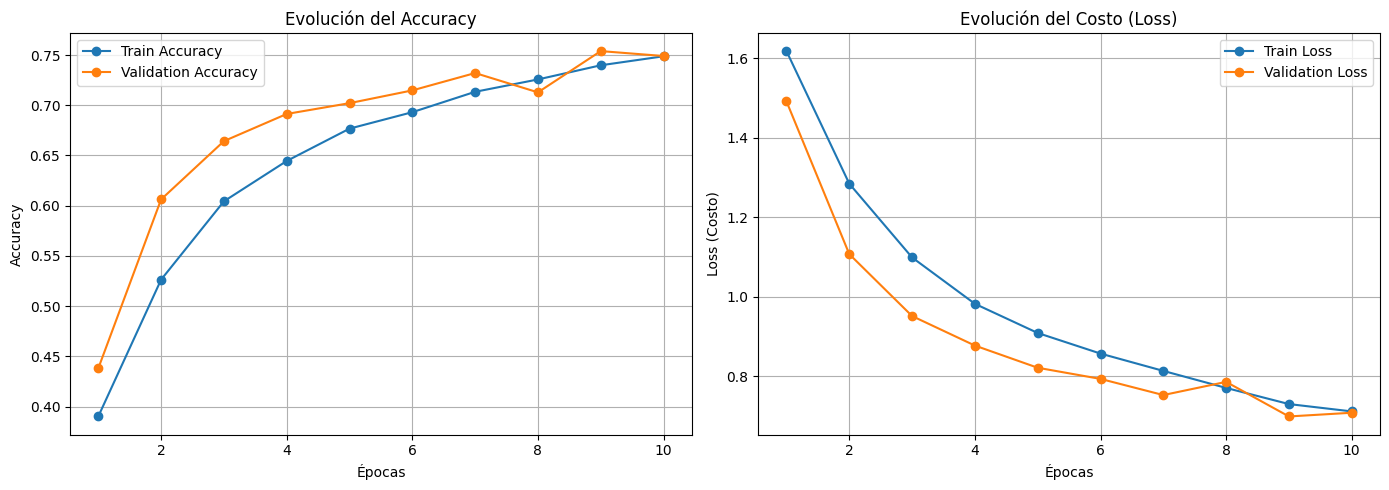

Evaluando el modelo en el conjunto de validación para obtener métricas...
--------------------------------------------------
Accuracy Final (Validación): 0.6587
F1 Score Macro Final (Validación): 0.4608
--------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

     alegria       0.86      0.83      0.84      1185
    disgusto       0.43      0.14      0.21       160
       enojo       0.68      0.37      0.48       162
       miedo       1.00      0.01      0.03        74
    seriedad       0.47      0.94      0.63       680
    sorpresa       0.86      0.40      0.54       329
    tristeza       0.66      0.38      0.49       478

    accuracy                           0.66      3068
   macro avg       0.71      0.44      0.46      3068
weighted avg       0.71      0.66      0.64      3068



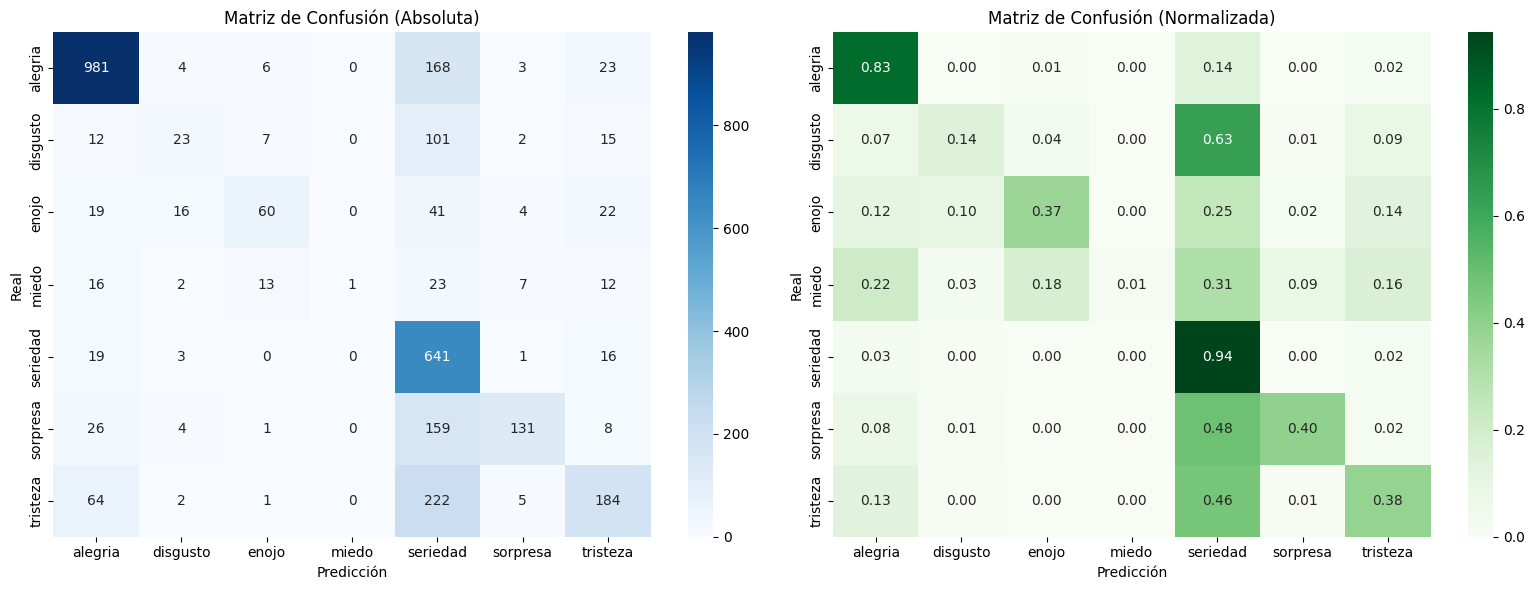

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import torch

# 1. Gráficas de Evolución (Accuracy y Loss)
epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Accuracy
axes[0].plot(epochs_range, history_train_acc, label='Train Accuracy', marker='o')
axes[0].plot(epochs_range, history_val_acc, label='Validation Accuracy', marker='o')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Evolución del Accuracy')
axes[0].legend()
axes[0].grid(True)

# Gráfica de Loss
axes[1].plot(epochs_range, history_train_loss, label='Train Loss', marker='o')
axes[1].plot(epochs_range, history_val_loss, label='Validation Loss', marker='o')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss (Costo)')
axes[1].set_title('Evolución del Costo (Loss)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 2. Evaluación final en el conjunto de validación
print("Evaluando el modelo en el conjunto de validación para obtener métricas...")
modelo.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = modelo(inputs)
        _, predicted = torch.max(outputs.data, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Nombres de las clases desde el dataset
class_names = [c for c in train_dataset.classes]

# Calcular métricas
final_accuracy = accuracy_score(y_true, y_pred)
final_f1_macro = f1_score(y_true, y_pred, average='macro')

print("-" * 50)
print(f"Accuracy Final (Validación): {final_accuracy:.4f}")
print(f"F1 Score Macro Final (Validación): {final_f1_macro:.4f}")
print("-" * 50)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Matrices de Confusión
cm_abs = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz Absoluta
sns.heatmap(cm_abs, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Matriz de Confusión (Absoluta)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Matriz Normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Matriz de Confusión (Normalizada)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 12 imágenes personales de cualquier ratio o relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación. Tampoco vale usar imágenes de otro dataset, deben ser imágenes sueltas.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones que durante el entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase esperada
  - La clase ganadora inferida por el modelo

- Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:

  - Similitudes entre emociones.
  - Mezcla de 2 o más emociones en una misma expresión.

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

**IMPORTANTE:** Ajusten los parámetros `scaleFactor`, `minNeighbors` y `minSize` según convenga para que la detección de rostros sea más efectiva y logre detectar rostros en sus 12 imágenes. No se queden necesariamente con los valores por defecto.